Build an SVM model to classify emails as Spam or Not Spam.

Dataset: Use any public dataset (e.g., SMS Spam Collection)

🧩 Tasks:
* Preprocess the dataset (handle categorical data, normalization, etc.)
* Split the dataset into training and testing sets
* Train an SVM model with at least two different kernels (e.g., linear and RBF)
* Compare the performance of the kernels
* Visualize decision boundaries (use 2 selected features for 2D visualization)
* Evaluate the model using accuracy, precision, recall, and F1-score


1. Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.decomposition import PCA

2. Load Dataset (DIRECTLY)

In [ ]:
categories = ['rec.autos', 'sci.med']

data = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

X_text = data.data
y = data.target

print("Sample Data:\n", X_text[0])


Sample Data:
 : My girlfriend is in pain from kidney stones. She says that because she has no
: medical insurance, she cannot get them removed.
: 
: My question: Is there any way she can treat them herself, or at least mitigate
: their effects? Any help is deeply appreciated. (Advice, referral to literature,
: etc...)
: 
: Thank you,
: 
: Dave Carvell
: pk115050@wvnvms.wvnet.edu

First off, I would consider the severity of the pain. I had stones
several years ago, and there's now way I could have made it without
heavy duty doses of morphine and demerol and a two week stay in the
hospital. I was told that there was nothing that I could take that would
dissolve them. If the stones are passible, the best thing she could do
is drink LOTS of water, and hope that they pass, but every time they
move a little, the pain will be excrutiating. I was told by my doctor
at that time that the pain was comparable to that of childbirth. (Yes,
by a male doctor, so I'm sure some of you women will disagre

 3. Preprocessing (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(X_text)


4. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

5. Train SVM Models

In [ ]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

SVC()

6. Predictions


In [ ]:
y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

7. Evaluation

In [ ]:
def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))


In [ ]:
evaluate(y_test, y_pred_linear, "Linear Kernel")
evaluate(y_test, y_pred_rbf, "RBF Kernel")


Linear Kernel
Accuracy : 0.9040404040404041
Precision: 0.9202127659574468
Recall   : 0.8826530612244898
F1 Score : 0.9010416666666666

RBF Kernel
Accuracy : 0.9292929292929293
Precision: 0.9329896907216495
Recall   : 0.923469387755102
F1 Score : 0.9282051282051282


Visualization

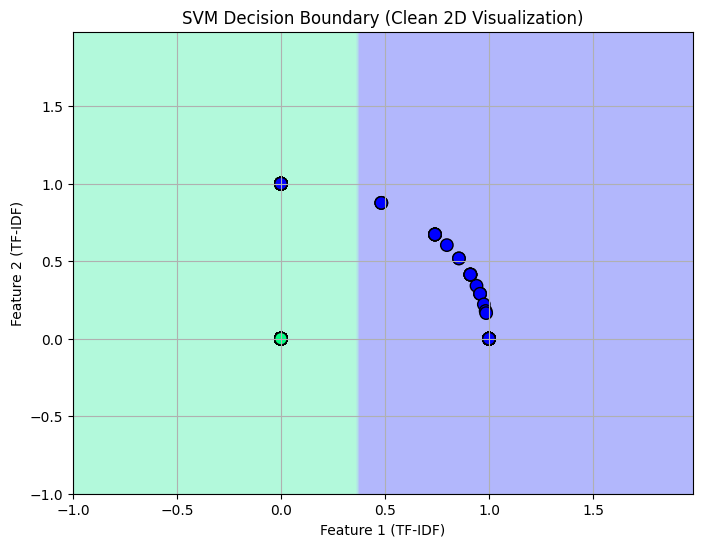

In [ ]:
vectorizer_2d = TfidfVectorizer(stop_words='english', max_features=2)
X_2d = vectorizer_2d.fit_transform(X_text).toarray()


X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

model_2d = SVC(kernel='linear')
model_2d.fit(X_train_2d, y_train_2d)


def plot_clean_boundary(model, X, y):
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="winter")

    plt.scatter(
        X[:, 0], X[:, 1],
        c=y,
        cmap="winter",
        edgecolors="k",
        s=80
    )

    plt.title("SVM Decision Boundary (Clean 2D Visualization)")
    plt.xlabel("Feature 1 (TF-IDF)")
    plt.ylabel("Feature 2 (TF-IDF)")
    plt.grid(True)
    plt.show()
plot_clean_boundary(model_2d, X_test_2d, y_test_2d)